<a href="https://colab.research.google.com/github/TRACE-Structures/digital_twinning/blob/main/demo/notebooks/data_driven_granada_hospital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data-Driven SHM of Hospital Real

This Jupyter Notebook demonstrates a data-driven approach to Structural Health Monitoring (SHM) using a real-world dataset from the Hospital Real building in Granada. The primary goal is to understand and correct for the influence of environmental factors—such as temperature and humidity—on structural modal properties, enabling more accurate detection of structural changes.

### Overview

- **Input Features**: Weather data  
  $$
  \mathbf{x} = [T, H]^T
  $$  
  where $T$ is temperature and $H$ is humidity.

- **Quantities of Interest**: Time series of frequencies and mode shapes  
  $$
  \mathbf{y} = [f_1, f_2, f_3, \dots, \boldsymbol{\psi}_1, \boldsymbol{\psi}_2, \boldsymbol{\psi}_3, \dots]
  $$

The input and output datasets are linked by timestamp indices.
Relevant modes and features are selected for modeling.

A **Linear Regression (LinReg)** model is trained on the input features to predict the frequencies and mode shapes.

**Sensitivity analyses** using Sobol indices are performed to understand the global influence of temperature and humidity.

**SHAP (SHapley Additive exPlanations)** values are computed to quantify the local impact of individual features on model predictions.

The **effects** of environmental variables are visualized and interpreted.

Finally, four different models trained on frequencies are compared to see how well they capture and correct for environmental effects:

* **gPCE (Generalized Polynomial Chaos Expansion)**: Models uncertainty by expressing the output as a polynomial expansion, with coefficients determined by projecting the system's response onto orthogonal polynomials.

* **DNN (Deep Neural Networks)**: Machine learning models composed of interconnected neurons, capable of learning complex, non-linear patterns from data.

* **GBT (Gradient Boosting Trees)**: Combines weak decision trees into a strong predictive model, iteratively correcting errors from previous trees for robust performance.

* **LinReg (Linear Regression)**: A statistical method that models the relationship between a dependent variable and one or more independent variables by fitting a linear equation to observed data.

### Data Source and Attribution
The data used in this notebook were provided by the University of Granada and were generated by Juan Chiachio Ruano and Emilio Daroch. The associated experiments were conducted on the cultural heritage building Hospital Real in Granada within the framework of the BUILDCHAIN project. We gratefully acknowledge their contribution and support.

Data Reuse Policy: The data may only be reused, redistributed, or referenced with appropriate attribution to the original authors and source, and by citing the corresponding repository: https://zenodo.org/records/17358241,  https://doi.org/10.5281/zenodo.17358241

# Imports

In [ ]:
!pip install digital_twinning

In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
import json
import digital_twinning
import digital_twinning.utils as utils
import uncertain_variables as uv
import pandas as pd
import requests

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Load data

### Load modeshape and weather data

In [3]:
data_path = 'https://raw.githubusercontent.com/TRACE-Structures/digital_twinning/main/demo/data/Granada/'

url = data_path + 'ref_modal_properties_2025-02-04-2026-02-04.unv'
r = requests.get(url)
r.raise_for_status()
with open("ref_modal_properties_2025-02-04-2026-02-04.unv", "wb") as f:
    f.write(r.content)

df_modeshapes = digital_twinning.df_from_unv('ref_modal_properties_2025-02-04-2026-02-04.unv')
weather_df = digital_twinning.preprocess_weather_data(data_path + 'ref_weather_data_2025-02-04_2026-02-04.csv')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Merge dataframes

In [4]:
merged_df = digital_twinning.merge_dataframes(df_modeshapes, weather_df)

modeshapes_dict = digital_twinning.separate__and_flip_modes(merged_df)
merged_df = digital_twinning.merge_modes(modeshapes_dict)

merged_df = digital_twinning.remove_constant_columns(merged_df)
merged_df.head(3)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Constant columns ['xi'] were found and excluded.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,phi_sensor_1_real,phi_sensor_1_imag,phi_sensor_2_real,phi_sensor_2_imag,phi_sensor_3_real,phi_sensor_3_imag,phi_sensor_4_real,phi_sensor_4_imag,phi_sensor_5_real,phi_sensor_5_imag,phi_sensor_6_real,phi_sensor_6_imag,Datetime,frequency,temperature_2m,relative_humidity_2m,mode_id
0,0.010114,0.029889,0.53301,-0.036790,0.090962,-0.015602,-0.063927,0.027691,1.0,0.0,0.137284,0.086598,2025-02-04 19:33:49,3.62425,9.75,86.766640,0
1,0.067700,0.073652,0.57011,-0.038071,0.069899,0.048334,0.000928,0.193863,1.0,0.0,0.143542,0.171055,2025-02-05 00:38:51,3.61993,5.70,87.893745,0
2,0.082362,0.080477,0.53645,0.000521,0.036294,0.080309,0.058879,0.149449,1.0,0.0,0.104144,0.184893,2025-02-05 02:38:51,3.71958,4.65,90.317630,0


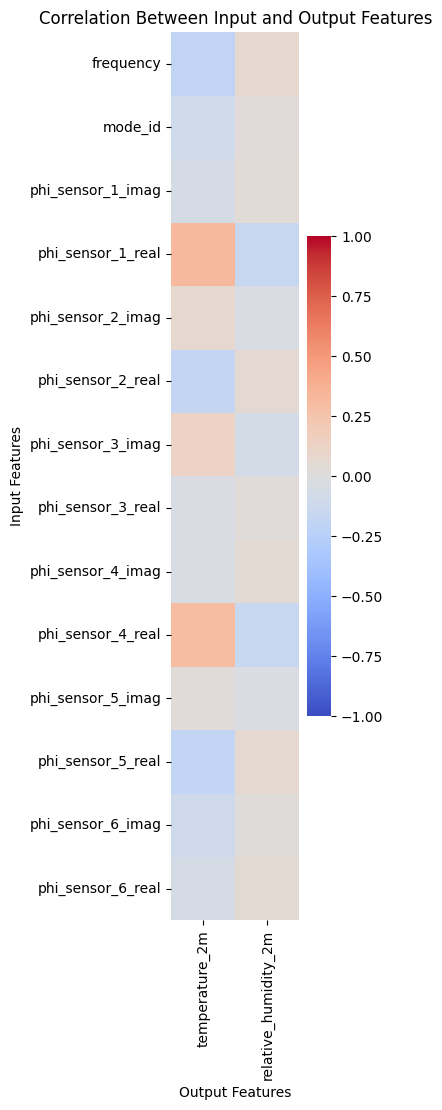

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
modeshape_cols = merged_df.columns.difference(weather_df.columns)
modeshapes_df = merged_df[modeshape_cols]

fig = digital_twinning.plot_correlation(modeshapes_df, weather_df, annot=False)

### Filter modes and features

In [6]:
# selecting modes to use
modes = [1,2,3]

# selecting environmental effects to use
X_cols = ['temperature_2m', 'relative_humidity_2m']

# choose from: frequency, frequency+modeshapes, modeshapes, or custom list of columns
y_cols = 'frequency'

X, y, Q, QoI_names = digital_twinning.select_cols(merged_df, modes, X_cols, y_cols)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### For training and sensitivity analysis

In [7]:
Q = digital_twinning.get_variableset_from_data(X)
QoI_names = y.columns.to_list()

max_index = 1
QoI_param = 'frequency_mode_2' # Quantity of Interest parameter

subtracted_effects = ['temperature_2m', 'relative_humidity_2m']

### For update

In [8]:
nwalkers = 64
nburn = 800
niter = 200

sigma = y.std(axis=0) # standard deviation of the data
E = uv.generate_stndrn_variable_set(sigma.values)

# Train model

### Model configurations

In [9]:
config_dnn = {
                'init_config' : {
                    'layers': [
                        {'neurons': 32, 'activation': 'relu', 'dropout': 0.1},
                        {'neurons': 64, 'activation': 'sigmoid', 'dropout': 0.1},
                        {'neurons': 128, 'activation': 'relu', 'dropout': None},
                        ],
                    'outputAF': 'tanh'
                    },
                'train_config' : {
                    'optimizer': 'Adam',
                    'loss': 'MSE',
                    'epochs': 200,
                    'batch_size': 32,
                    'k_fold': None,
                    'early_stopping': {
                        'patience': 50,
                        'min_delta': 0.0001}
                    }
}

config_gbt = {
    'init_config' : {
        'gbt_method': 'xgboost'
    },
    'train_config' : {
        'max_depth': 6,
        'num_of_iter': 250,
        'k_fold': 5
        }
}

config_gpce = {
    'init_config' : {
    'p' : 2
    },
    'train_config' : {
        'k_fold': 5
        }
}
config_linreg = {
    'init_config': {},
    'train_config': {}
}

config = {'LinReg': config_linreg, 'DNN': config_dnn, 'GBT': config_gbt, 'gPCE': config_gpce}

In [10]:
split_config = {
        'train_test_ratio': 0.8,
        'random_seed': 1997,
        'split_type': 'shuffle'
}

In [11]:
method = 'gPCE'

In [12]:
mask = y.notna().all(axis=1)
y_clean = y[mask]
X_clean = X.loc[mask]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
# Initialize surrogate model
model = digital_twinning.DataDrivenModel(Q, QoI_names, method, **config.get(method)['init_config'])
# Split data into training and testing sets
X_train, X_test, y_train, y_test = model.train_test_split(X_clean, y_clean, **split_config)
y_train = y_train.dropna()
# Train the model
model.train(X_train, y_train, **config.get(method)['train_config'])
metrics, agg_metrics = model.evaluate_model(y_train, X_test, y_test, verbose=False)
print('\nEvaluation metrics:')
metrics.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----- Training started for 'gPCE' model -----
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Average train loss: 0.00663990751797, Average valid loss: 0.00669206838172
----- Training ended for 'gPCE' model -----

Evaluation metrics:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Kendall_tau,Pearson,Spearman,MSE,MAE,RMSE,STD_of_label,NRMSE,NMAE,rel_RMSE,summed_metric
Output_Name,,,,,,,,,,,
frequency_mode_1,0.425588,0.707350,0.594607,0.002180,0.034883,0.046690,0.069626,0.119764,0.089478,0.670580,0.352322
frequency_mode_2,0.330088,0.632485,0.470751,0.009028,0.069077,0.095015,0.124650,0.102577,0.074575,0.762255,0.223689
frequency_mode_3,0.301736,0.593350,0.432925,0.007786,0.068672,0.088237,0.115108,0.133510,0.103907,0.766561,0.187150


In [14]:
# get mean and variance of surrogate model
mean, var = model.get_mean_and_var()
mean, var

(array([3.91386165, 5.29908382, 5.90166904]),
 array([0.00411599, 0.01156049, 0.00908775]))

## Sobol sensitivities

In [15]:
# set max_index for Sobol sensitivity analysis
max_index = 2
partial_variance, sobol_index = model.get_sobol_sensitivity(max_index)

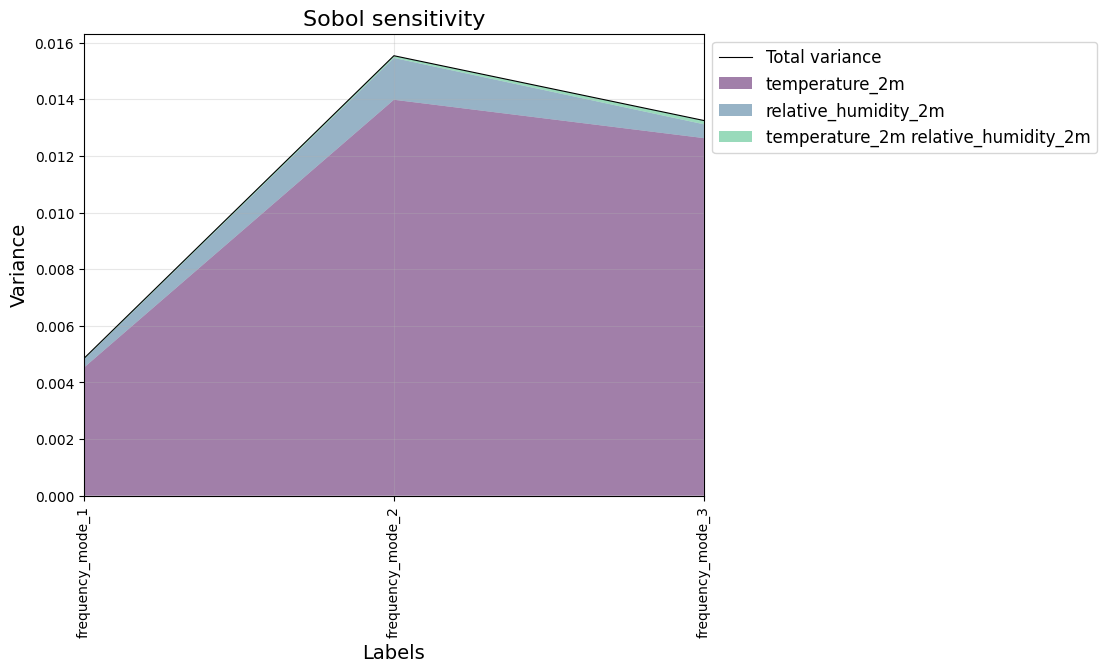

In [16]:
# Plot Sobol Sensitivity Index
# The 'plot_sobol_sensitivity' method generates a plot of Sobol Sensitivity indices, which quantify
# the contribution of each input parameter to the output uncertainty.
# - max_index: Specifies the maximum index of parameters to consider in the plot.
# - param_name: The name of the quantity of interest (QoI) for which sensitivity is being calculated ('frequency_mode_2' in this case).
fig = model.plot_sobol_sensitivity(y_train, max_index)

/usr/local/lib/python3.12/dist-packages/digital_twinning/utils/utils.py:136: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  remaining = [y_var_df.loc[param_name][0], 1] - df.sum()


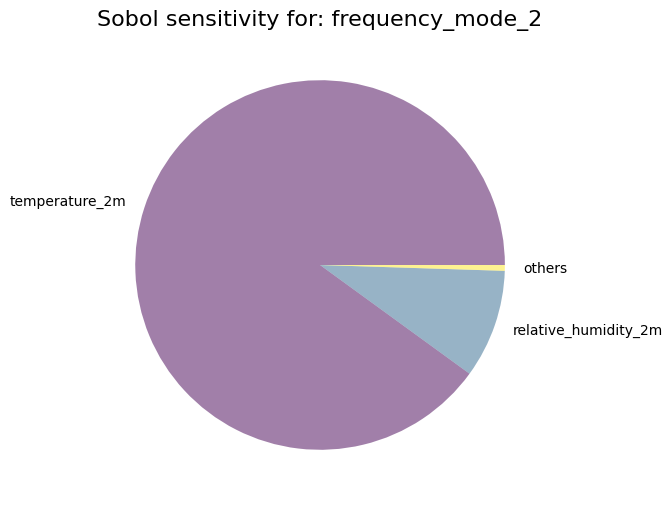

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
fig = model.plot_sobol_sensitivity(y_train, max_index=max_index, param_name=QoI_param)

## SHAP values

In [18]:
# Calculate SHAP (Shapley Additive Explanations) values
# The 'get_shap_values' method computes the SHAP values for the model's test data (model.X_test).
# SHAP values explain the contribution of each input feature to the prediction for each test sample.
# SHAP values help to interpret the model's decisions and understand the impact of each input parameter on the output.
shap_values = await model.get_shap_values(X_test)

Message: sample size for shap values is set to 100.


  0%|          | 0/100 [00:00<?, ?it/s]

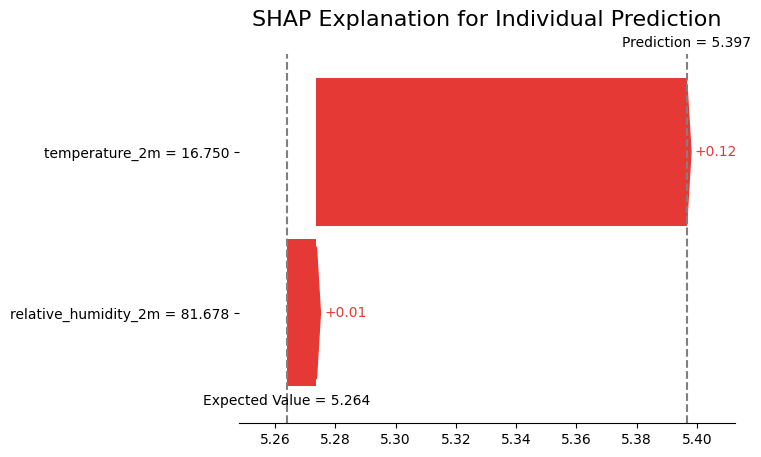

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [19]:
# Plot SHAP Single Waterfall Plot
# The 'plot_shap_single_waterfall' method generates a SHAP waterfall plot for a single test sample,
# visualizing how each feature contributes to the model's prediction for that sample.
# - q: A DataFrame containing the sample data (e.g., a specific parameter set) for which the SHAP values are calculated.
# - param_name: The name of the quantity of interest (QoI) being analyzed ('frequency_mode_1' in this case).
# The SHAP waterfall plot shows the cumulative effect of each feature on the model's prediction, helping to interpret individual predictions.
fig = await model.plot_shap_single_waterfall(X_test, q=X_test, param_name=QoI_param, silent=True)

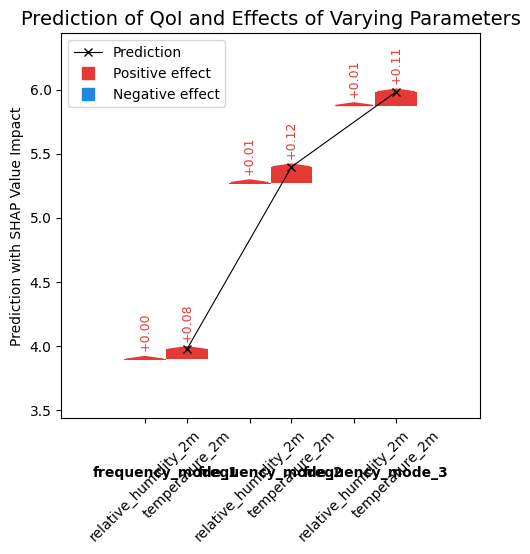

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
fig = await model.plot_shap_multiple_waterfalls(X_test, q=X_test, silent=True)

/usr/local/lib/python3.12/dist-packages/digital_twinning/utils/utils.py:446: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(QoI_shap, q, show=False)


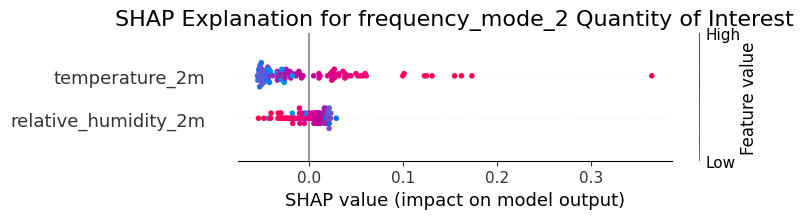

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
# Plot SHAP Beeswarm Plot
# The 'plot_shap_beeswarm' method generates a SHAP beeswarm plot, which visualizes the distribution of SHAP values
# for a range of test samples, showing the impact of each feature on the model’s predictions.
# - q: The test data (X_test.iloc[:100]) is selected for which SHAP values are calculated and visualized.
# - param_name: The name of the quantity of interest (QoI) for which SHAP values are computed ('frequency_mode_1' in this case).
# The SHAP beeswarm plot shows how different input features influence the predictions across multiple samples,
# helping to understand the global feature importance and the relationships between features and the target.
fig = await model.plot_shap_beeswarm(X_test, param_name=QoI_param, silent=True)

## Effects

In [22]:
# Load and preprocess monitoring data

url = data_path + 'modal_properties_2026-02-04-2026-06-04.unv'
r = requests.get(url)
r.raise_for_status()
with open("modal_properties_2026-02-04-2026-06-04.unv", "wb") as f:
    f.write(r.content)

monitor_df_modeshapes = digital_twinning.df_from_unv('modal_properties_2026-02-04-2026-06-04.unv')
monitor_weather_df = digital_twinning.preprocess_weather_data(data_path + 'weather_data_2026-02-04_2026-06-04.csv')

monitor_merged_df = digital_twinning.merge_dataframes(monitor_df_modeshapes, monitor_weather_df)
monitor_modeshapes_dict = digital_twinning.separate__and_flip_modes(monitor_merged_df)
monitor_merged_df = digital_twinning.merge_modes(monitor_modeshapes_dict)
monitor_merged_df = digital_twinning.remove_constant_columns(monitor_merged_df)
monitor_X, monitor_y, monitor_Q, monitor_QoI_names = digital_twinning.select_cols(monitor_merged_df, modes, X_cols, y_cols)
mask = monitor_y.notna().all(axis=1)
monitor_y = monitor_y[mask]
monitor_X = monitor_X.loc[mask]

Constant columns ['xi'] were found and excluded.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Message: sample size for shap values is set to 1094, which is the number of samples.


  0%|          | 0/1094 [00:00<?, ?it/s]

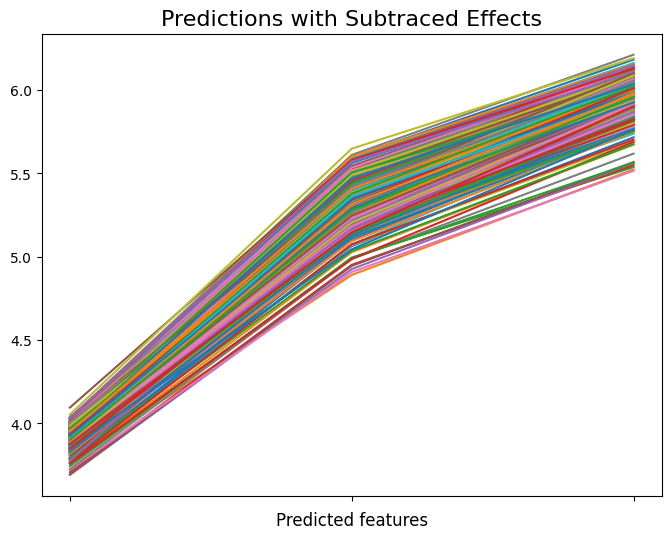

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
effects = await model.subtract_effects(monitor_X, monitor_y, subtracted_effects)
fig = await model.plot_effects(effects, xticks=False)

Message: sample size for shap values is set to 2360, which is the number of samples.


  0%|          | 0/2360 [00:00<?, ?it/s]

Message: sample size for shap values is set to 1094, which is the number of samples.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  0%|          | 0/1094 [00:00<?, ?it/s]

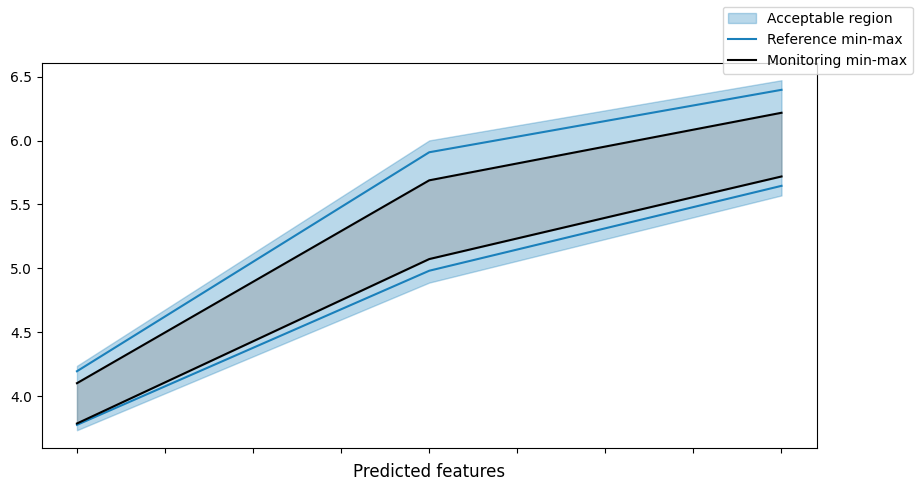

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [24]:
fig, alert, remained_effects_df, error_ratio, problematic_rows, reference_statistics, monitoring_statistics = await model.plot_subtract_effects_and_alert(X_train, y_train, monitor_X, monitor_y, subtracted_effects[1:], xticks=False)

## Comparing models

In [25]:
# selecting modes to use
modes = [2]

# selecting environmental effects to use
X_cols = ['temperature_2m', 'relative_humidity_2m']

# choose from: frequency, frequency+modeshapes, modeshapes, or custom list of columns
y_cols = 'frequency'

X, y, Q, QoI_names = digital_twinning.select_cols(merged_df, modes, X_cols, y_cols)

mask = y.notna().all(axis=1)
y_clean = y[mask]
X_clean = X.loc[mask]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
model_types = ['LinReg', 'DNN', 'GBT', 'gPCE']
metrics_all = []

for model_type in model_types:
    model = digital_twinning.DataDrivenModel(Q, QoI_names, model_type, **config.get(model_type)['init_config'])
    X_train, X_test, y_train, y_test = model.train_test_split(X_clean, y_clean, **split_config)
    model.train(X_train, y_train, **config.get(model_type)['train_config'])
    metrics, agg_metrics = model.evaluate_model(y_train, X_test, y_test, verbose=False)
    metrics['Model Name'] = model_type
    metrics = metrics.reset_index()
    metrics_all.append(metrics)

metrics = pd.concat(metrics_all, axis=0)
col = metrics.pop('Model Name')
metrics.insert(0, 'Model Name', col)
print('\nEvaluation metrics:')
metrics

----- Training started for 'LinReg' model -----
Average train loss: 0.01063914791324, Average valid loss: 0.01155231835256
----- Training ended for 'LinReg' model -----
Using device: cpu
----- Training started for 'DNN' model -----


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch [0/200], train loss: 0.0529, validation loss: 0.0168
Epoch [50/200], train loss: 0.0086, validation loss: 0.0090
Early stopping triggered after 95 epochs!
Training stopped early. Restoring best model (monitored val_loss = 0.0090).
Average train loss: 0.00873654533519, Average valid loss: 0.00895232708202
----- Training ended for 'DNN' model -----
----- Training started for 'GBT' model -----
Fold 1/5
Fold 2/5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fold 3/5
Fold 4/5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fold 5/5
Average train loss: 0.00152543280274, Average valid loss: 0.01128043066710
----- Training ended for 'GBT' model -----
----- Training started for 'gPCE' model -----
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Average train loss: 0.00923483911158, Average valid loss: 0.00927450600794
----- Training ended for 'gPCE' model -----

Evaluation metrics:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Model Name,Output_Name,Kendall_tau,Pearson,Spearman,MSE,MAE,RMSE,STD_of_label,NRMSE,NMAE,rel_RMSE,summed_metric
0,LinReg,frequency_mode_2,0.349029,0.579522,0.500486,0.011396,0.079275,0.106750,0.125275,0.117277,0.087092,0.852125,0.192304
0,DNN,frequency_mode_2,0.385647,0.685959,0.543912,0.009013,0.070020,0.094935,0.125275,0.104297,0.076925,0.757812,0.285902
0,GBT,frequency_mode_2,0.317788,0.604178,0.455322,0.011525,0.077507,0.107356,0.125275,0.117942,0.085150,0.856960,0.173443
0,gPCE,frequency_mode_2,0.371501,0.667860,0.526110,0.009480,0.071664,0.097364,0.125275,0.106965,0.078731,0.777200,0.262757
